In [40]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import statsmodels.api as sm 
from statsmodels.stats.outliers_influence import variance_inflation_factor

mysite_palette = ['#375a7f', "#ff879b", '#189cd0', "#c46151", "#18bc9c", "#54011a", '#2c3e50']
plt.rcParams['axes.prop_cycle'] = cycler(color=mysite_palette) 


url = 'https://www.kaggle.com/datasets/nancyalaswad90/diamonds-prices/data'
#path = kagglehub.dataset_download("nancyalaswad90/diamonds-prices")
#for f in os.listdir(path):
    #fromPath = os.path.join(path, f)
    #os.rename(fromPath, f'../data/{f}')

### Intro

Two months after completing my MSBA degree, I'm looking to do a quick refresher of some basic data science principles. The MSBA program developed a broad array of capabilities, and I'd like to ensure I keep those skills fresh even if I don't have consistent opporuntities to employ them in the workplace. 

Searched Kaggle for a suitable dataset to train a ML model to predict some response based on some combination of available features. This diamonds dataset is reminiscent of examples from early class lectures.

Goals:
- Restrict use of any GenAI tools, limiting myself to my memory or reference of past projects and assignments
- Conduct exploratory data analysis to understand the dataset, its features, and which are most likely significant
- Determine if any initial data transformations are needed
- Start simple with an OLS model, assessing significance of potential features and validity of model assumptions
- If appropriate/applicable, progress toward exploring alternative model types and/or further feature transformations
- As a finishing step, embed a simple interactive app to generate predicted prices based on UI slider inputs

In [41]:
df = pd.read_csv('../data/Diamonds Prices2022.csv', index_col=0).reset_index(drop=True)
display(df.info())
display(df.head())
display(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53943 entries, 0 to 53942
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53943 non-null  float64
 1   cut      53943 non-null  object 
 2   color    53943 non-null  object 
 3   clarity  53943 non-null  object 
 4   depth    53943 non-null  float64
 5   table    53943 non-null  float64
 6   price    53943 non-null  int64  
 7   x        53943 non-null  float64
 8   y        53943 non-null  float64
 9   z        53943 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


None

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


,carat,depth,table,price,x,y,z
count,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000
mean,0.797935,61.749322,57.457251,3932.734294,5.731158,5.734526,3.538730
std,0.473999,1.432626,2.234549,3989.338447,1.121730,1.142103,0.705679
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.000000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [42]:
for col in df.columns:
    if df[col].dtype == 'object':
        vc = df.value_counts(col).reset_index()
        vc['percent'] = np.round(vc['count']*100/df.shape[0], 2)
        display(vc)

,cut,count,percent
0,Ideal,21551,39.95
1,Premium,13793,25.57
2,Very Good,12083,22.40
3,Good,4906,9.09
4,Fair,1610,2.98


,color,count,percent
0,G,11292,20.93
1,E,9799,18.17
2,F,9543,17.69
3,H,8304,15.39
4,D,6775,12.56
5,I,5422,10.05
6,J,2808,5.21


,clarity,count,percent
0,SI1,13067,24.22
1,VS2,12259,22.73
2,SI2,9194,17.04
3,VS1,8171,15.15
4,VVS2,5066,9.39
5,VVS1,3655,6.78
6,IF,1790,3.32
7,I1,741,1.37


In order for these categorical variables to be plotted and interpreted correctly by models, I'll need to explicitly set them to categorical variables, ensuring I capture their order correctly. It's been a few years since I've been shopping for a diamond, so I had to Google search these clarity and color tiers, as well as the meaning of the table variable.

In [43]:
df.cut = pd.Categorical(df.cut, categories=['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'], ordered=True)
color_letters = sorted(df.color.unique(), reverse=True)
df.color = pd.Categorical(df.color, categories=color_letters, ordered=True)
df.clarity = pd.Categorical(df.clarity, categories=['I3', 'I2', 'I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'], ordered=True)

With the categorical variables handled, I'd like to get some quick visual plots to see better understand the distributions of the variables in the dataset. 

Notably, many of the variables demonstrate a roughly normal distribution, including color, clarity, depth, and table. However, both price and carat are strongly right-skewed. Carat exhibits an interesting stepped behavior with higher frequencies just near certain thresholds like 1.0, 1.5, or 2.0 carats. I imagine this is not random but the result of conscious efforts to achieve specific final diamond weights when being cut and finished. 

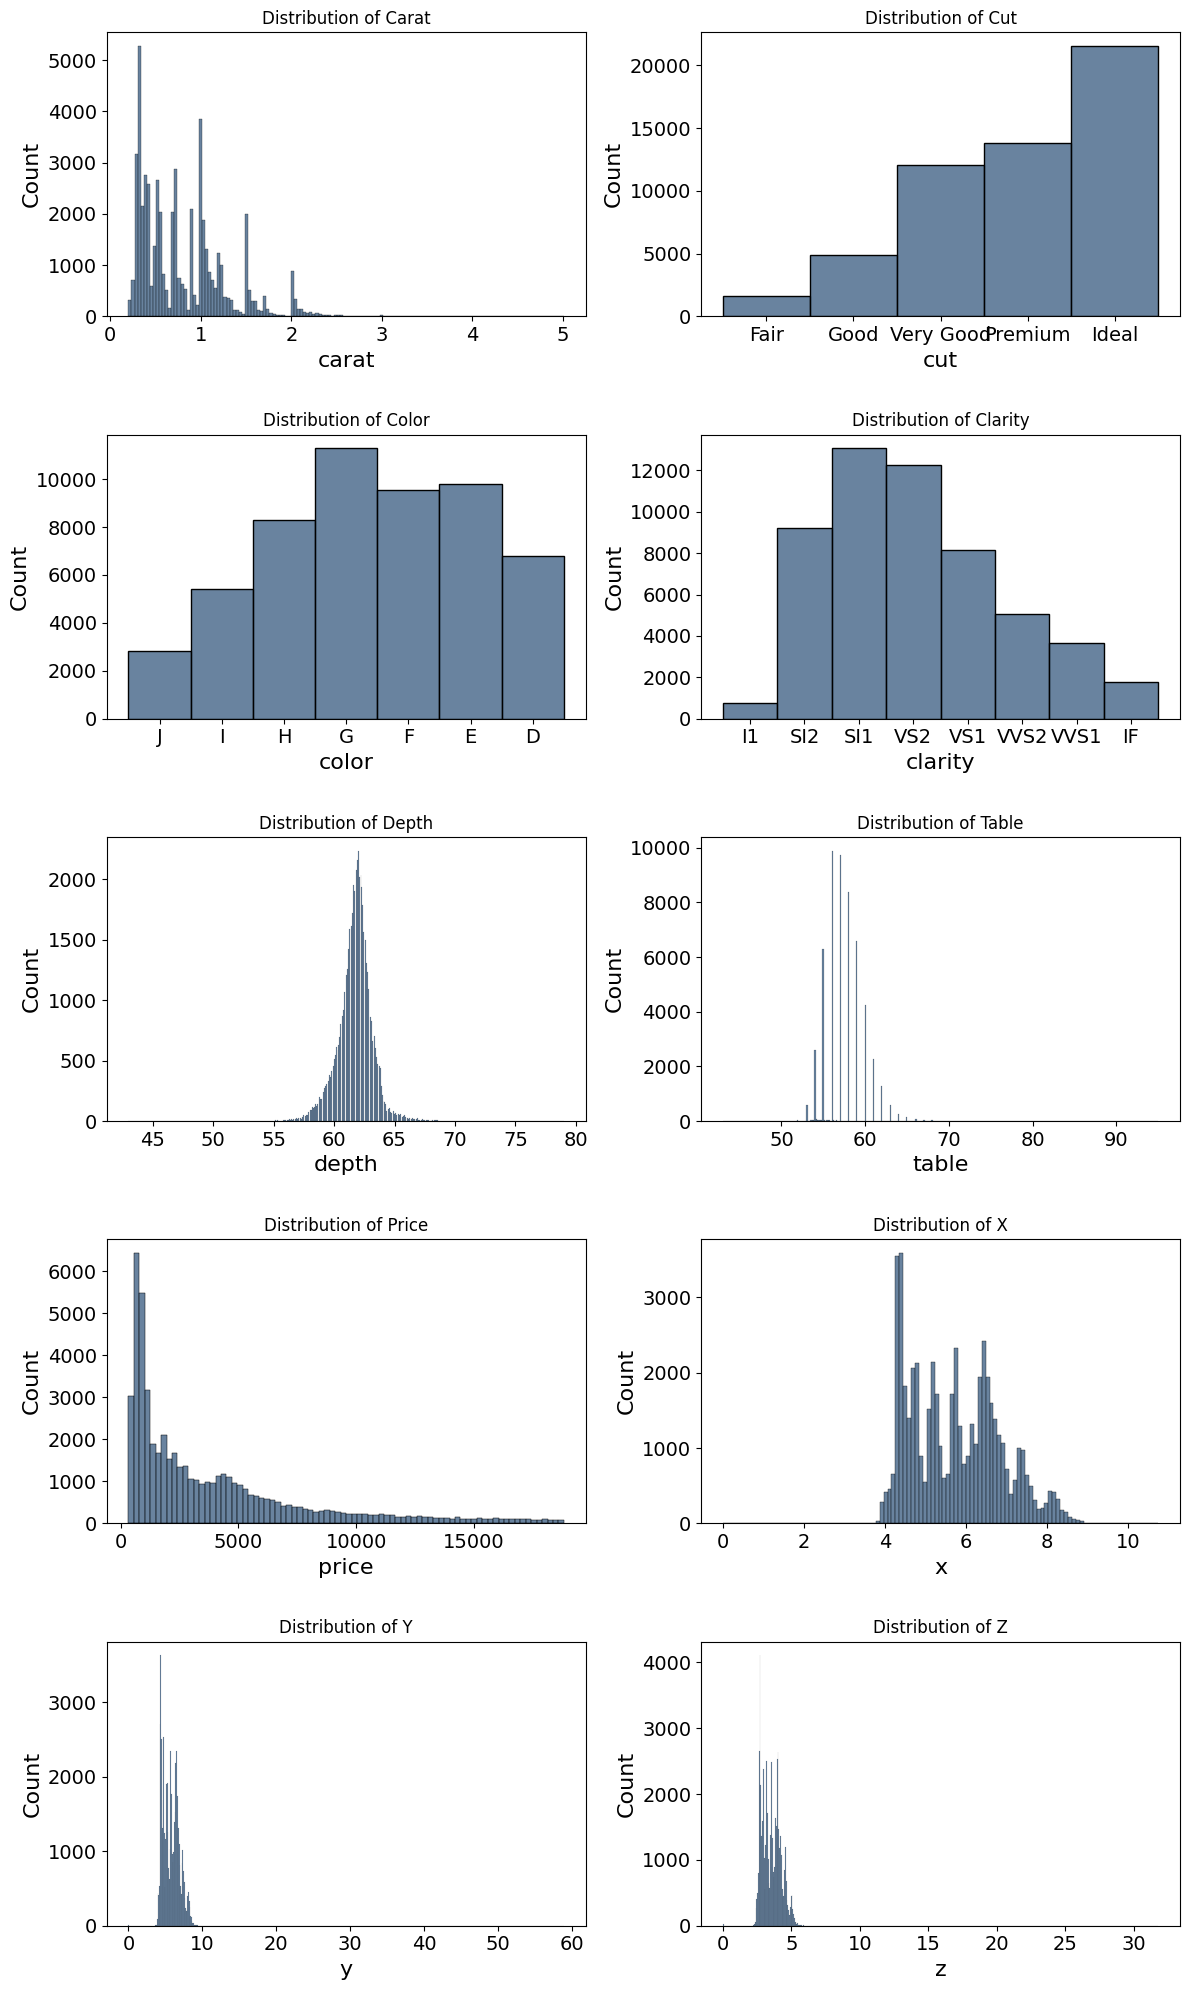

In [44]:
n_axes = df.shape[1]
n_plot_rows = int(np.ceil(n_axes/2))

fig, axes = plt.subplots(n_plot_rows, 2, figsize=(12,n_plot_rows*4))
axes = axes.flatten()

for a, col in enumerate(df.columns):
    sns.histplot(df[col], ax=axes[a])
    axes[a].set_title(f'Distribution of {col.capitalize()}')

plt.tight_layout(h_pad=3)
plt.show()


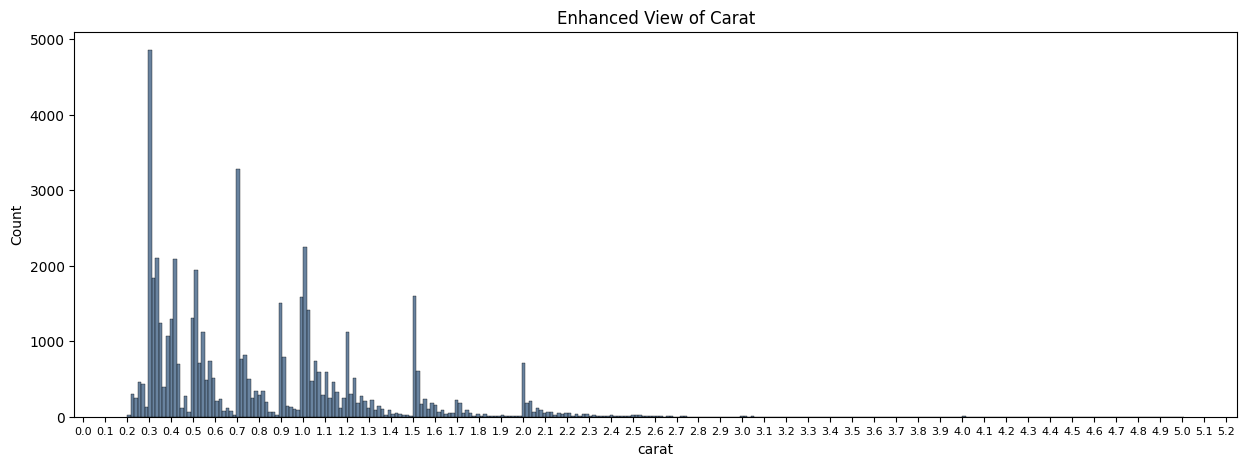

In [ ]:
plt.figure(figsize=(15,5))
plt.rcParams.update(
    {'xtick.labelsize': 8, 'ytick.labelsize': 10, 'axes.labelsize': 10}
)
plt.rcParams.clear
plt.xticks(np.arange(0, 6, 0.1), labels=None)
sns.histplot(df.carat, bins=300)
plt.title('Enhanced View of Carat')
plt.show()

Thinking about the variables x, y, and z, which represent the length, width, and depth of the of the stone in mm, it seems potentially useful to know if the diamond is something like a round cut where the length and width would be (nearly) the same, or if it's a more irregular shape such as an oval where there length and width would be markedly different. I'll create a new variable, assessing whether the length is +/-5% different than the width. As plotted below, you can see the segregation of two groups, the majority which are roughly equal in dimension, and a minority that are irregular.

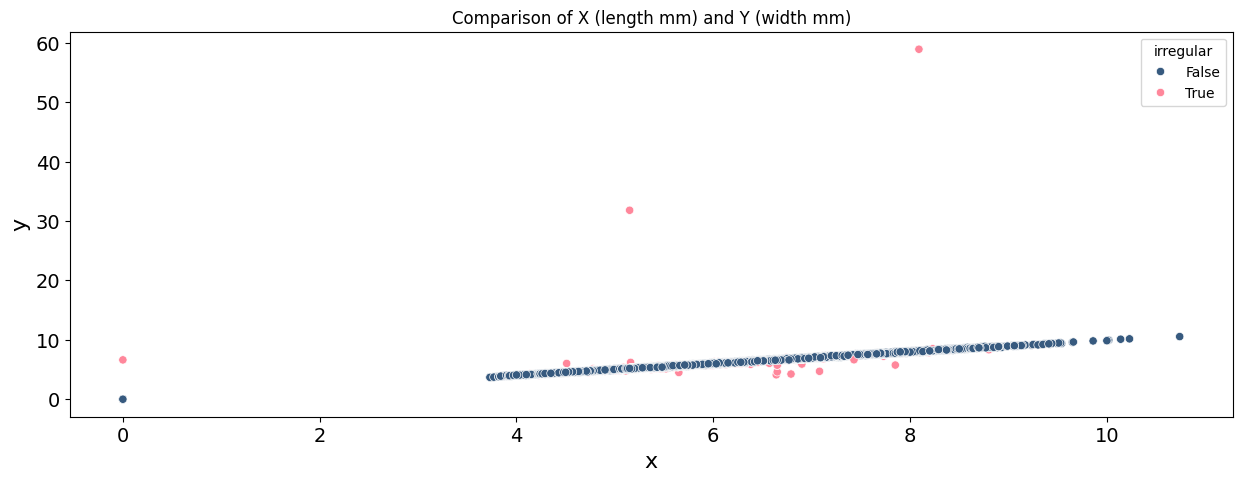

In [46]:
df['irregular'] = np.abs((df.x - df.y) / df.y) > 0.03
plt.figure(figsize=(15,5))
sns.scatterplot(df, x=df.x, y=df.y, hue=df.irregular)
plt.title('Comparison of X (length mm) and Y (width mm)')
plt.show()

The scatterplot of length x width also revealed what appear to be 4 erroneous data points. Diamonds with length = 0 will be excluded from further analysis, as well as the two with widths more than 6x great than their length as these are obviously not accurate. I will take a moment to reflect on this and it's relation to a concept I've been reading about recently that technical skills without proper domain knowledge are insufficient. I'm far from a diamond expert, but without at least enough domain knowledge to know that a diamond cannot be 8mm x 60mm, these data points would have remained in the training data passed to the model(s).

In [47]:
df['erroneous'] = (df.x == 0) | (df.y > 20)
erroneous = df.copy().loc[df.erroneous]
cleaned = df.copy().loc[~df.erroneous]
print(f'''
{df.shape[0]} original rows
{erroneous.shape[0]} rows removed
{cleaned.shape[0]} rows remaining''')


53943 original rows
10 rows removed
53933 rows remaining


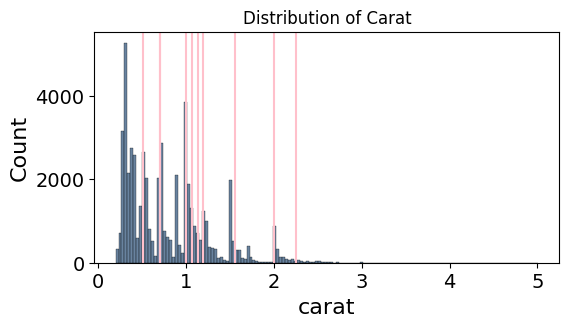

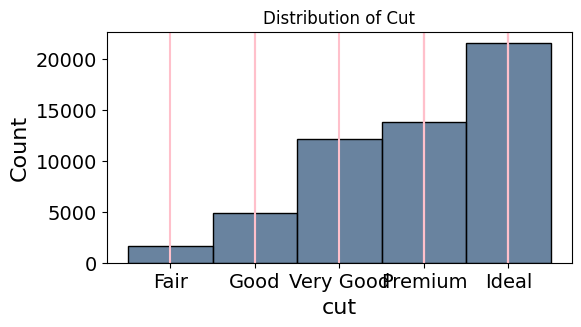

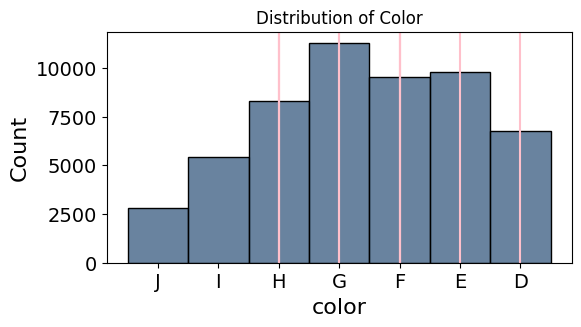

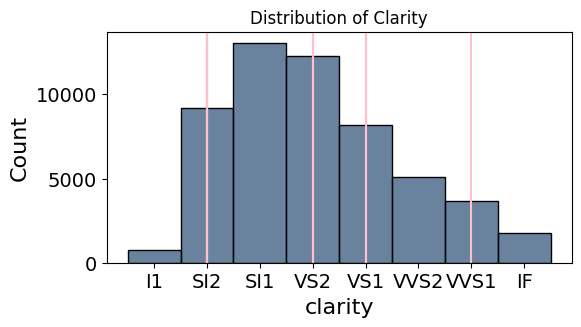

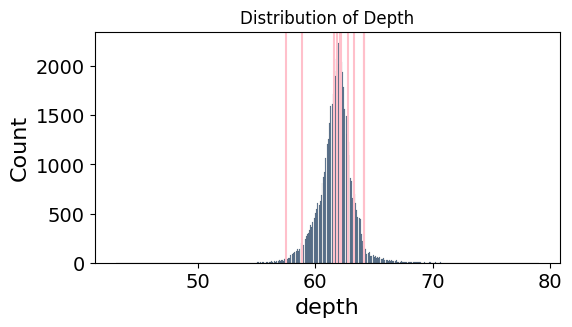

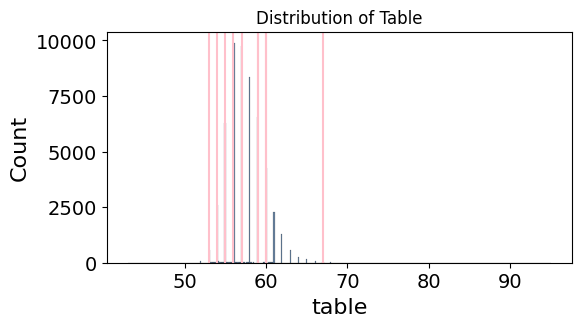

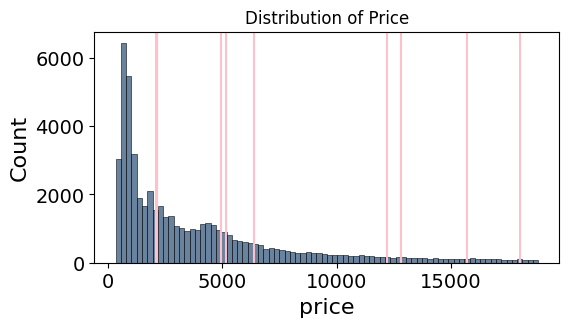

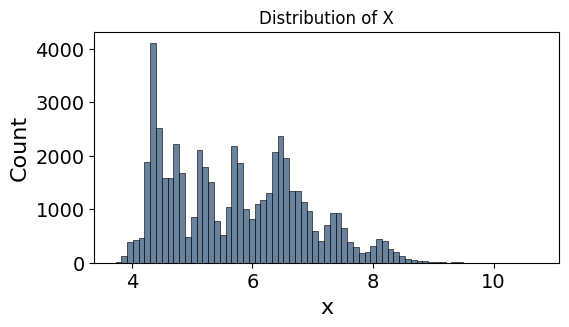

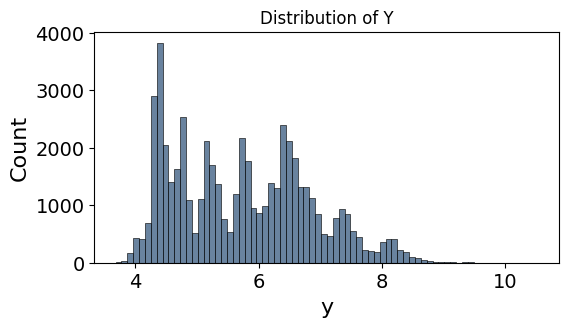

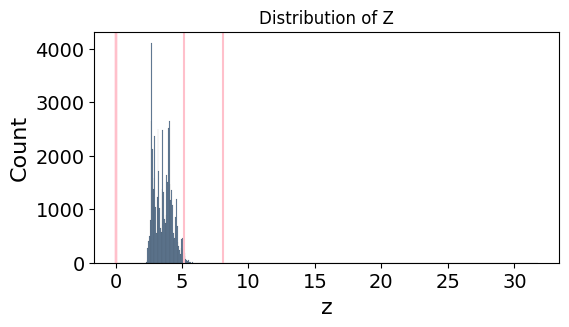

In [48]:
for col in cleaned.columns:
    if col not in ['irregular', 'erroneous']:
        plt.figure(figsize=(6,3))
        plt.title(f'Distribution of {col.capitalize()}')
        sns.histplot(cleaned[col])
        if col not in ['x', 'y']:
            for i in range(erroneous.shape[0]):
                plt.axvline(x=erroneous.iloc[i][col], color='pink')

        plt.show()

We now see a much more logical pattern displayed in the plot of length x width, with most still being regularly shaped (nearly identical) and a minority being irregular. Notable is also the individual distributions of x and y look more as one would expect, but that of z still looks quite off. Given that at least some data quality issues have been found thus far, it would be prudent to check the z values, would in theory, should be well related to the depth variable (ratio of z to y).

*Though removing 10 rows out of 53k shouldn't present any bias issues, I've overlaid distributions of those removed rows' values to double check, and we can see that they are generally random.

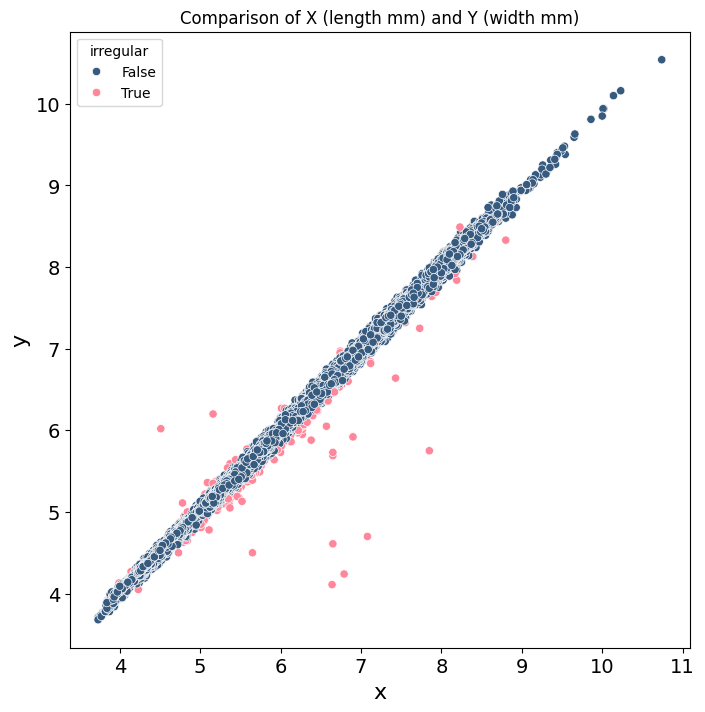

In [49]:
cleaned['irregular'] = np.abs((cleaned.x - cleaned.y) / cleaned.y) > 0.03
plt.figure(figsize=(8,8))

sns.scatterplot(cleaned, x='x', y='y', hue='irregular', )
plt.title('Comparison of X (length mm) and Y (width mm)')
plt.show()

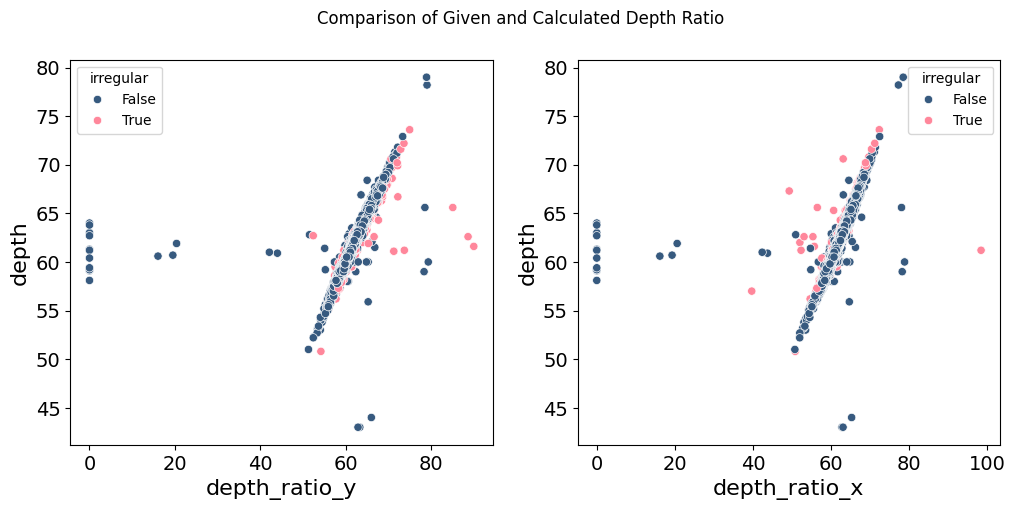

In [50]:
cleaned['depth_ratio_x'] = cleaned.z / cleaned.x * 100
cleaned['depth_ratio_y'] = cleaned.z / cleaned.y * 100
fig, axes = plt.subplots(1, 2, figsize=(12,5))
fig.suptitle('Comparison of Given and Calculated Depth Ratio')
sns.scatterplot(cleaned.loc[cleaned.depth_ratio_y < 100], x='depth_ratio_y', y='depth', hue='irregular', ax=axes[0])
sns.scatterplot(cleaned.loc[cleaned.depth_ratio_x < 100], x='depth_ratio_x', y='depth', hue='irregular', ax=axes[1])

plt.show()

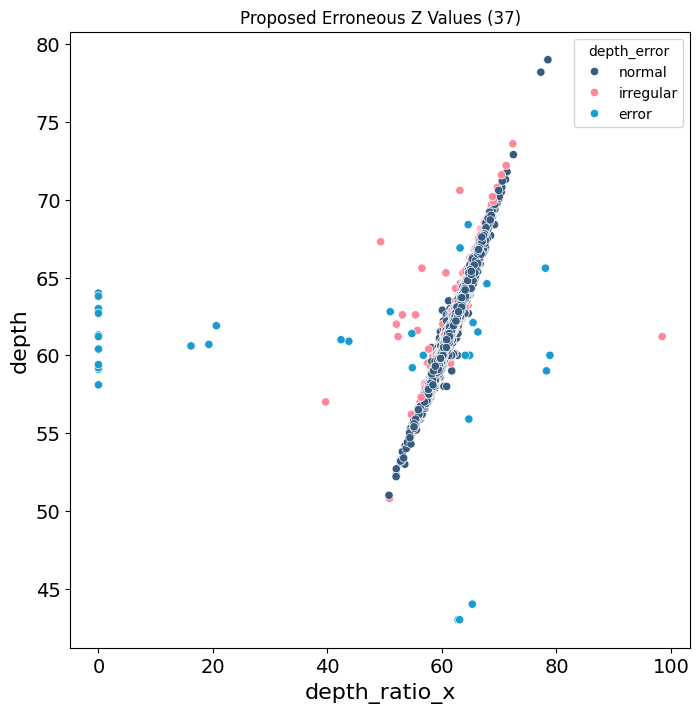

In [51]:
def assign_depth_error(row):
    if row.irregular:
        return 'irregular'
    elif (np.abs(row.depth_ratio_x - row.depth) > 3):
        return 'error'
    else:
        return 'normal'
    
cleaned['depth_error'] = cleaned.apply(assign_depth_error, axis=1)

plt.figure(figsize=(8, 8))
sns.scatterplot(cleaned.loc[cleaned.depth_ratio_x < 100], x='depth_ratio_x', y='depth', hue='depth_error')
plt.title(f'Proposed Erroneous Z Values ({cleaned.loc[cleaned.depth_error == "error"].shape[0]})')
plt.show()

Generally, the calculated depth ratio here should align with the given ratio under the 'depth' variable. However, as this ratio takes the diamond's depth and divides by width, and some of these diamonds have irregular sizes, I cannot be certain in how the given depth values were produced, e.g. was width considered width, length, or some average of the two? For this reason, I'll give those irregular diamonds a 'pass' here and focus on identifying the other outliers.

Since the number of rows with apparent erroneous values (column z) is once again such a small proportion of the total data, I will exclude these rows.

In [52]:
depth_errors = cleaned.copy().loc[cleaned.depth_error=='error']
cleaned_2 = cleaned.copy().loc[cleaned.depth_error!='error']
print(f'''
{cleaned.shape[0]} original rows
{depth_errors.shape[0]} rows removed
{cleaned_2.shape[0]} rows remaining''')


53933 original rows
37 rows removed
53896 rows remaining


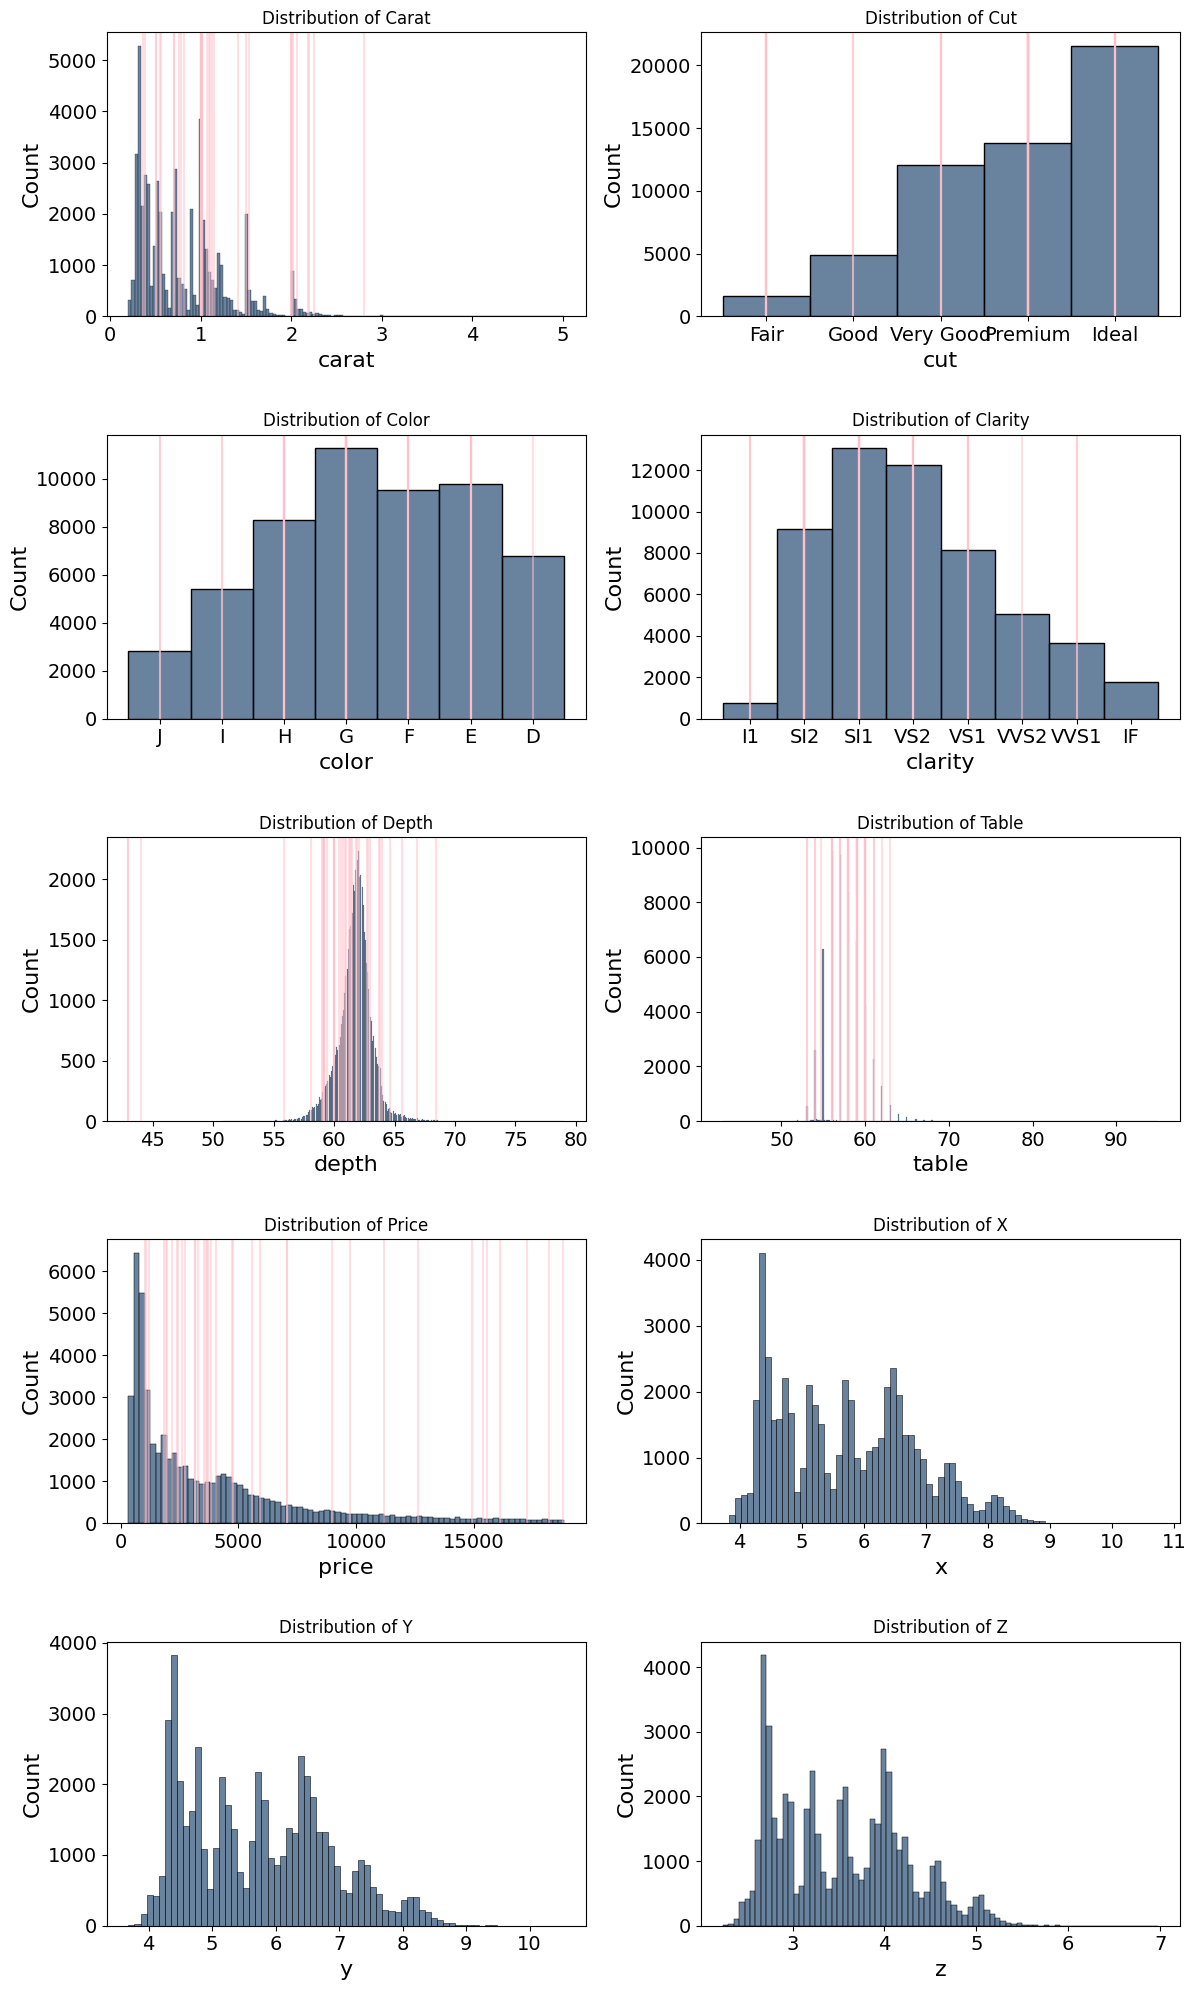

In [53]:
check_cols = [col for col in cleaned_2 if col not in ['irregular', 'erroneous', 'depth_ratio_x', 'depth_ratio_y', 'depth_error']]

n_axes = len(check_cols)
n_plot_rows = int(np.ceil(n_axes/2))

fig, axes = plt.subplots(n_plot_rows, 2, figsize=(12,n_plot_rows*4))
axes = axes.flatten()

for a, col in enumerate(check_cols):
    axes[a].set_title(f'Distribution of {col.capitalize()}')
    sns.histplot(cleaned_2[col], ax=axes[a])
    if col not in ['x', 'y', 'z']:
        for i in range(depth_errors.shape[0]):
            axes[a].axvline(x=depth_errors.iloc[i][col], color='pink', alpha=.5)

plt.tight_layout(h_pad=3)
plt.show()

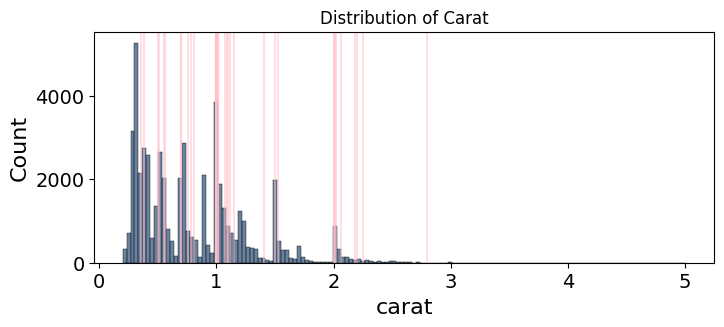

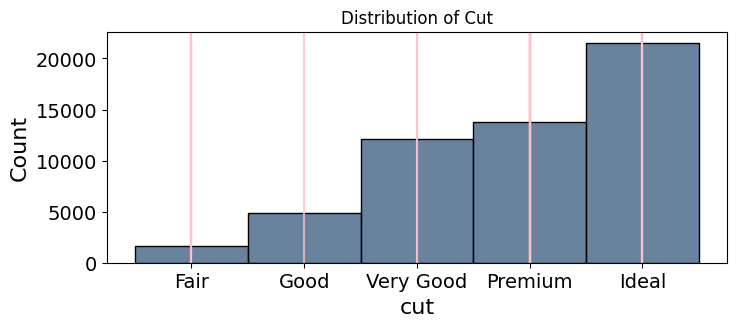

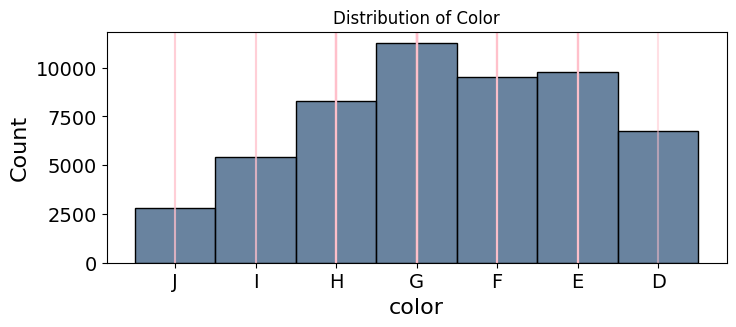

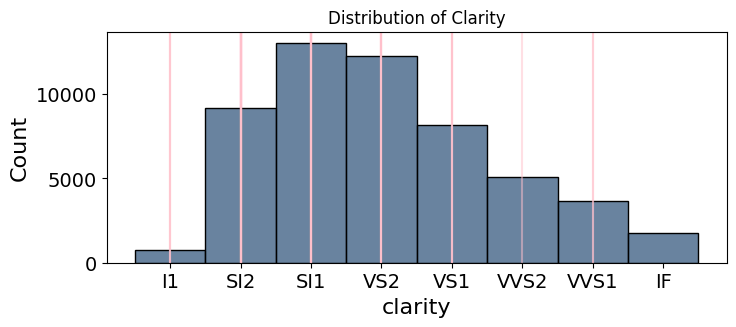

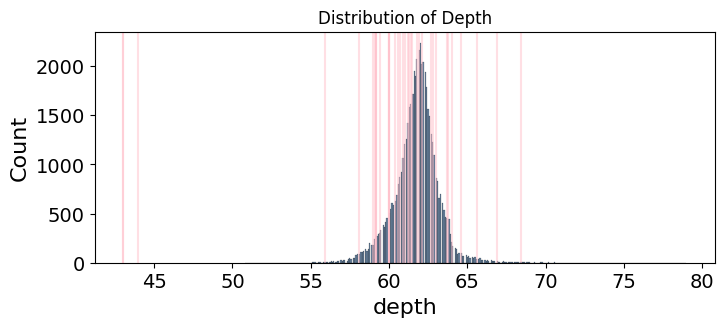

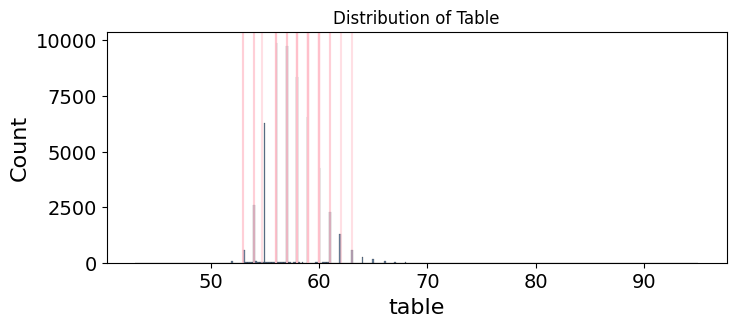

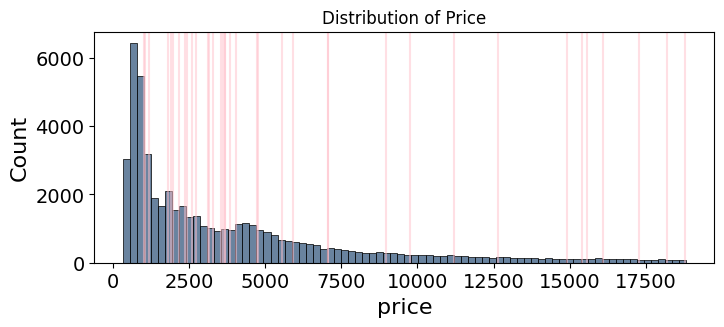

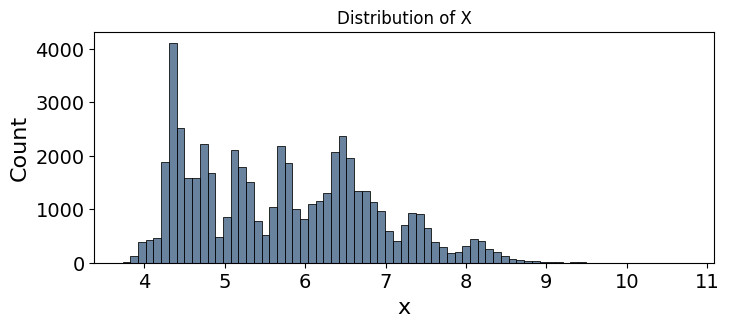

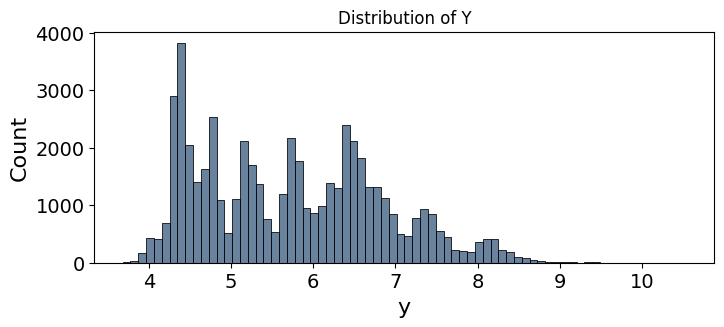

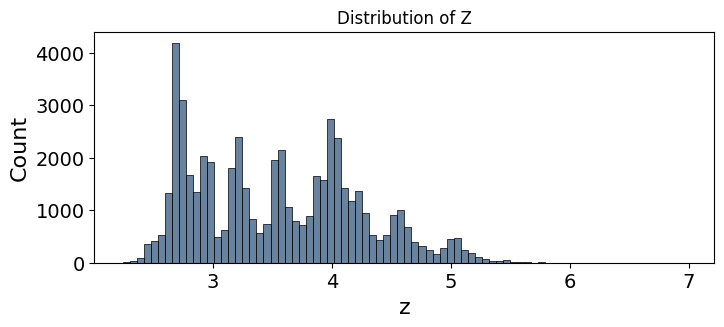

In [54]:
for col in cleaned_2.columns:
    if col not in ['irregular', 'erroneous', 'depth_ratio_x', 'depth_ratio_y', 'depth_error']:
        plt.figure(figsize=(8,3))
        plt.title(f'Distribution of {col.capitalize()}')
        sns.histplot(cleaned_2[col])
        if col not in ['x', 'y', 'z']:
            for i in range(depth_errors.shape[0]):
                plt.axvline(x=depth_errors.iloc[i][col], color='pink', alpha=.5)

        plt.show()

Once again we see fairly even/random distribution of other column values for the rows removed due to erroneous z value, so no significant bias concern.

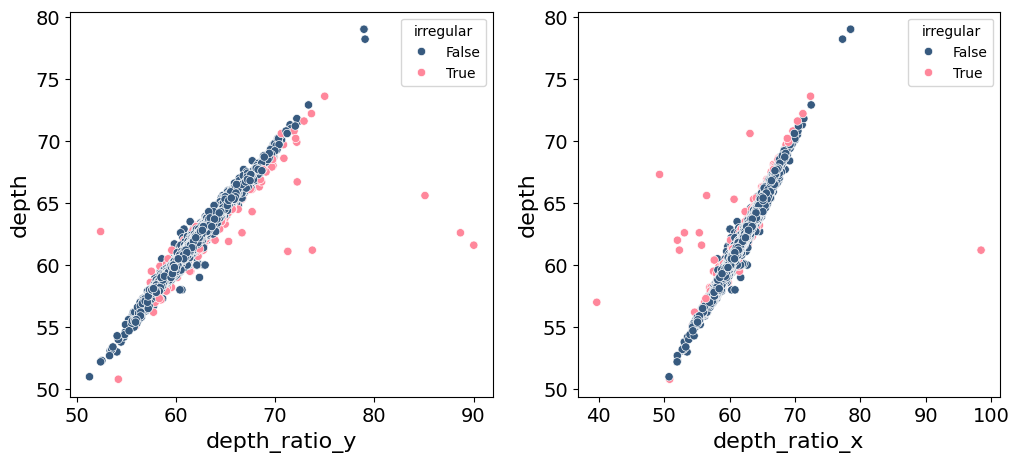

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.scatterplot(cleaned_2, x='depth_ratio_y', y='depth', hue='irregular', ax=axes[0])
sns.scatterplot(cleaned_2, x='depth_ratio_x', y='depth', hue='irregular', ax=axes[1])

plt.show()

What we see now is much closer to an expected linear pattern between the given and calculated depth ratios, aside from those diamonds with irregular width/length sizes. The individual histograms of each dimension variable also look more appropriate and aligned.

With these dimensional values cleaned up, it's time to check out the relationships between the response, price, and the potential model features.

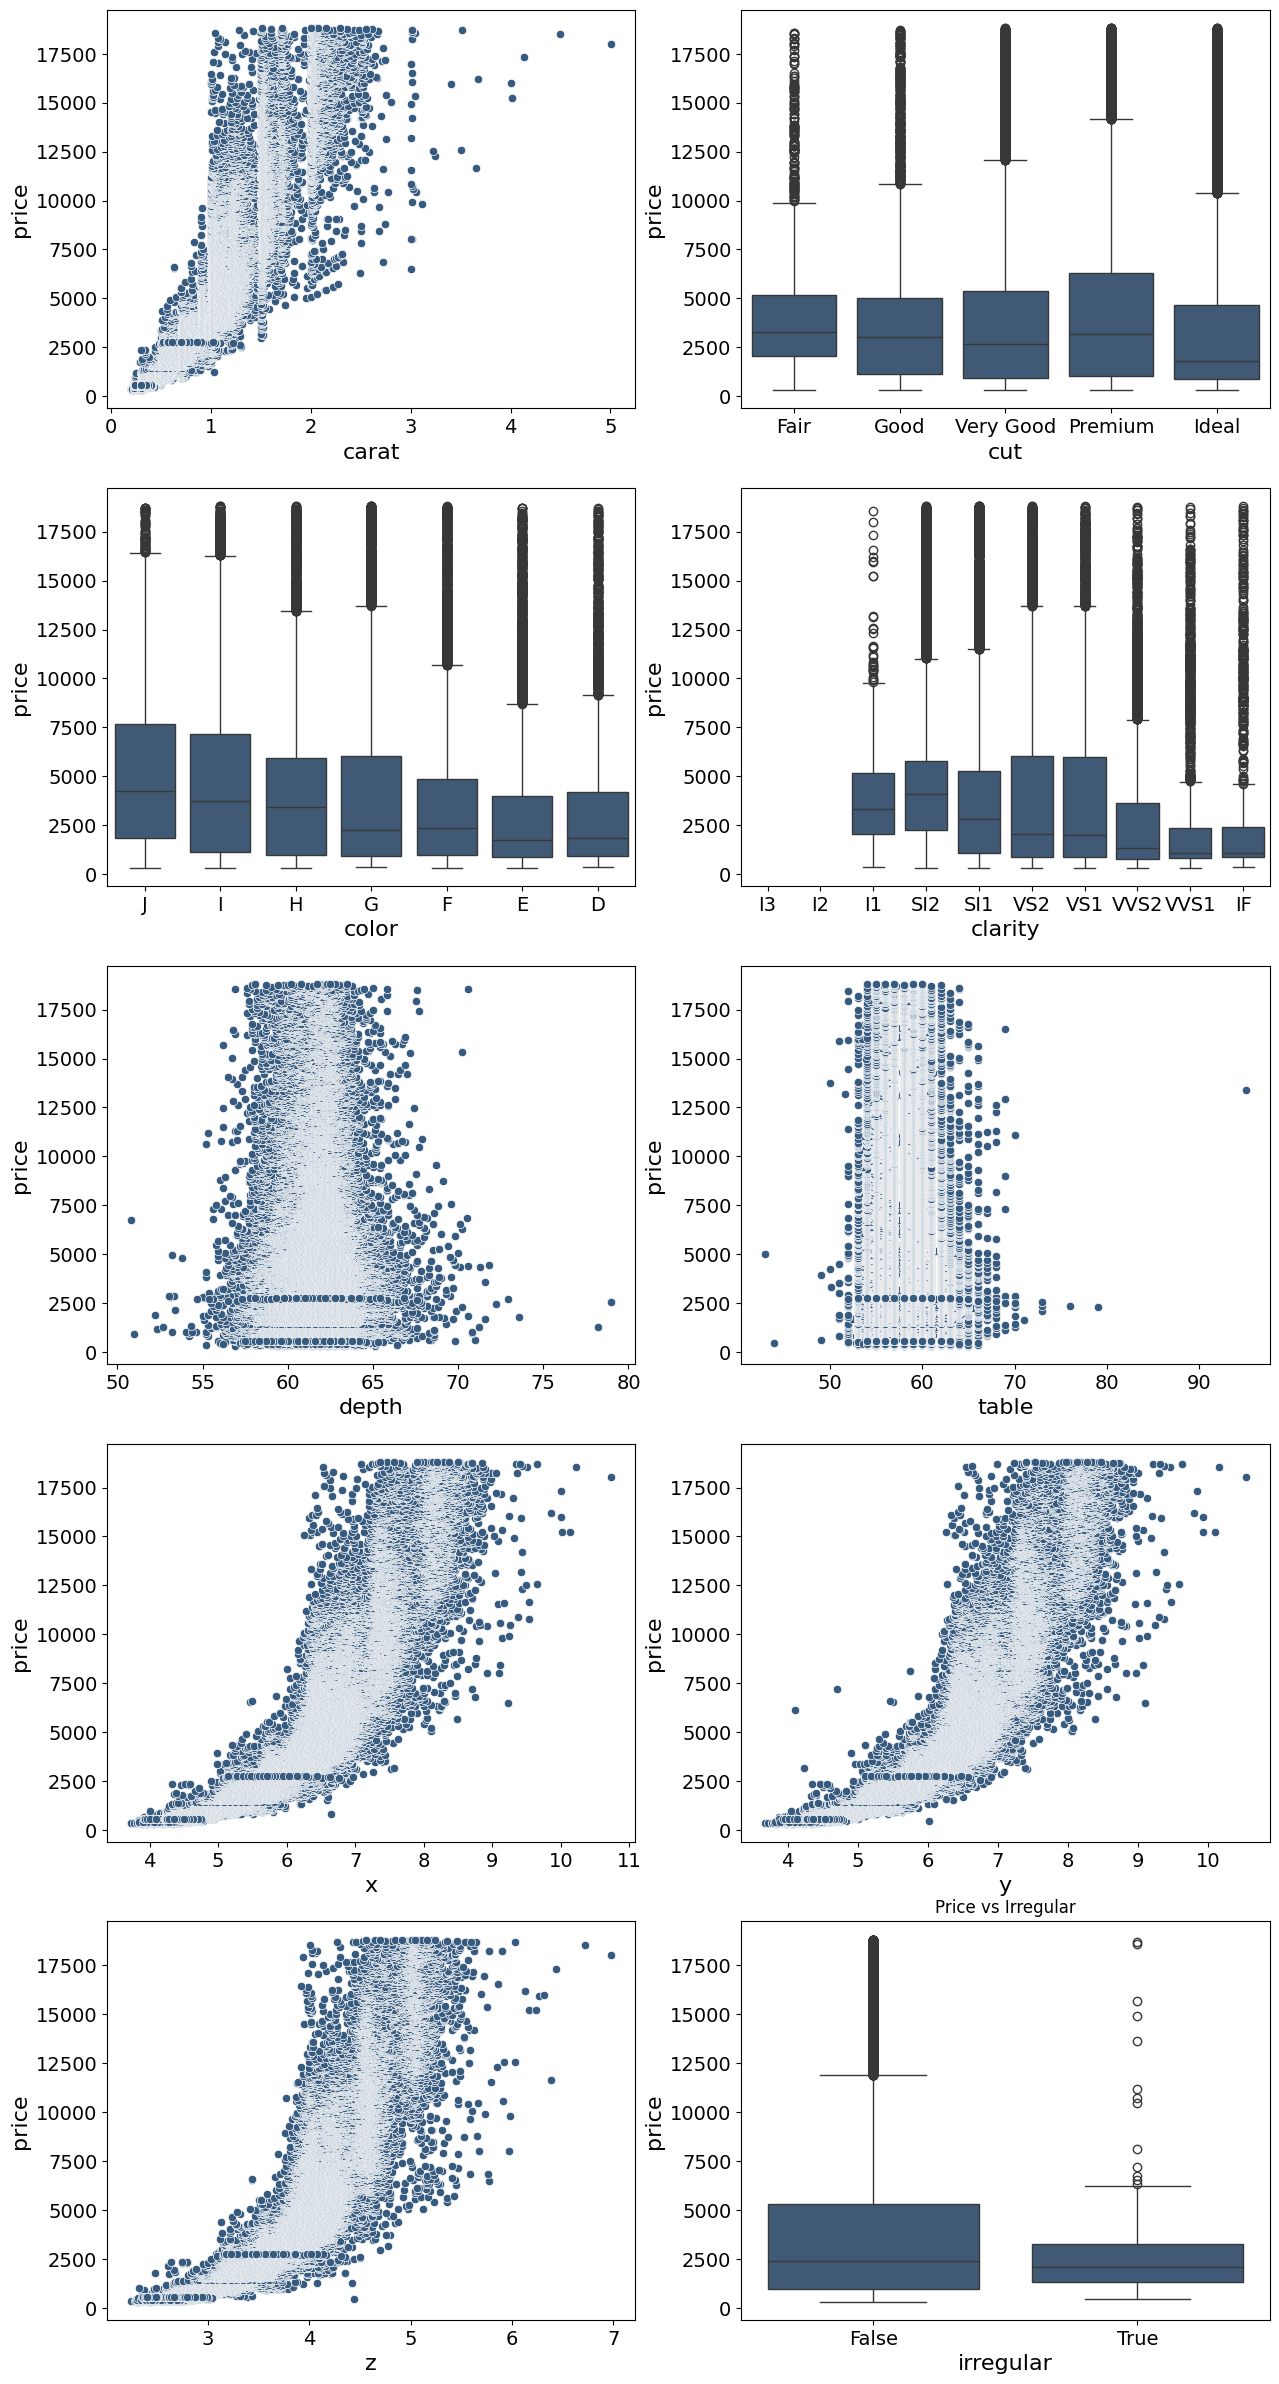

In [56]:
cdf = cleaned_2.copy().drop(columns=['erroneous', 'depth_ratio_x', 'depth_ratio_y', 'depth_error'])
evar_cols = [c for c in cdf.columns if c != 'price']
n_axes = len(evar_cols)
n_plot_rows = int(np.ceil(len(evar_cols)/2))

fig, axes = plt.subplots(n_plot_rows, 2, figsize=(15,30))
axes = axes.flatten()

for a, col in enumerate(evar_cols):
    if cdf[col].dtype == 'category' or col == 'irregular':
        sns.boxplot(cdf, x=col, y='price', ax=axes[a])
    else:
        sns.scatterplot(cdf, x=col, y='price', ax=axes[a])

    plt.title(f'Price vs {col.capitalize()}')

plt.show()

<Axes: xlabel='depth', ylabel='Count'>

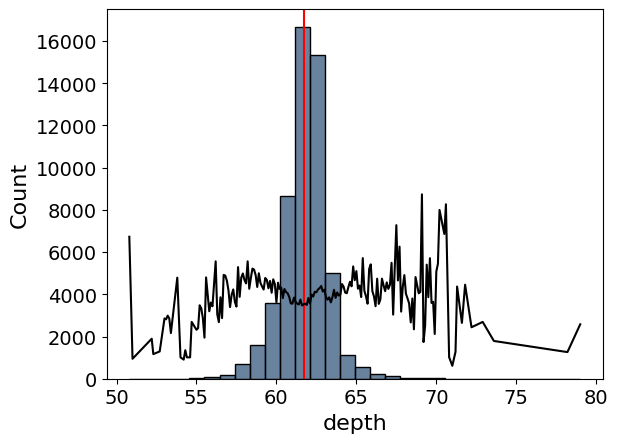

In [57]:
sns.histplot(cleaned_2, x='depth', bins=30)
plt.axvline(x=cleaned_2.depth.mean(), color='red')
grp = cleaned_2.groupby('depth').agg(avg_pr=('price', 'mean'))
sns.lineplot(grp, x='depth', y='avg_pr', color='black')

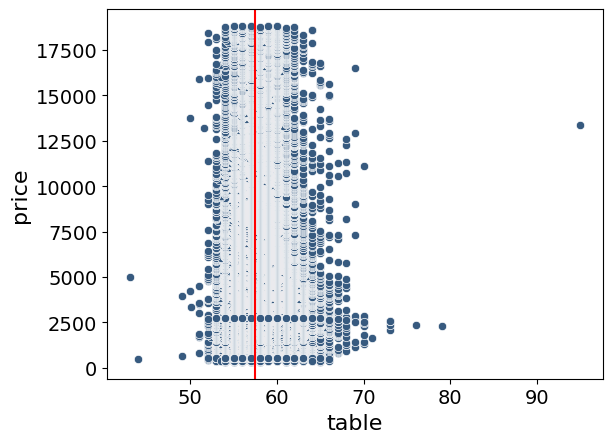

In [58]:
#sns.histplot(cleaned_2, x='table', bins=30)
sns.scatterplot(cleaned_2, x='table', y='price')
plt.axvline(x=cleaned_2.table.mean(), color='red')
grp = cleaned_2.groupby('table').agg(avg_pr=('price', 'mean'))
#sns.lineplot(grp, x='table', y='avg_pr', color='black')

Analyzing these plots, it would appear the variable with the strongest correlation to price is carat, as well as the dimensional variables x, y, and z, which makes sense given that carat is after all a measure of the diamonds weight.

The boxplots of cut, color, and clarity all show the opposite of what I would have expected, generally lower median prices as you move along the categories from worst to best. More notable than that though is that each category of each variable contains a large number of outliers, reaching up to the highest prices points.

Another notable observation is that there's slightly more variation in depth, and to a lesser extent, table, at the lower prices than there is at higher prices. This is consistent with what I've read that there is an ideal central range of ratios for these.

Thinking that the heavily skewed distributions of price and carat may be impairing the ability to gain insights from their plots. I'm going to examine some potential transformations of both variables. For the remaining features, I'll look to examine their isolated plots with ceterus parabus.

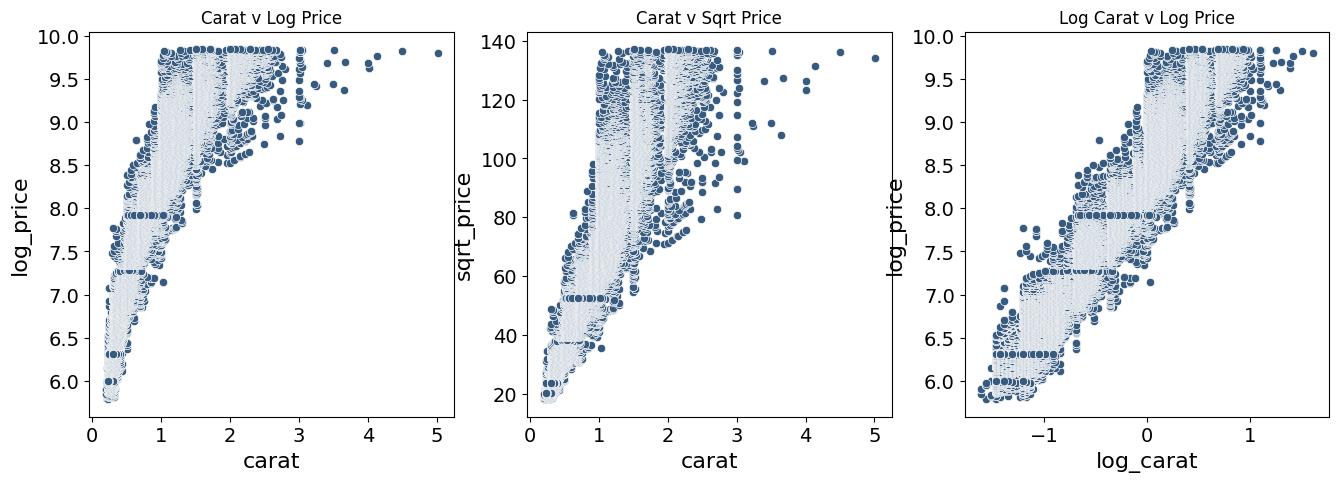

In [59]:
cdf = cleaned_2.copy().drop(columns=['erroneous', 'depth_ratio_x', 'depth_ratio_y', 'depth_error'])
cdf['log_price'] = np.log(cdf.price)
cdf['sqrt_price'] = cdf.price**(1/2)
cdf['log_carat'] = np.log(cdf.carat)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.scatterplot(cdf, x='carat', y='log_price', ax=axes[0])
axes[0].set_title('Carat v Log Price')
sns.scatterplot(cdf, x='carat', y='sqrt_price', ax=axes[1])
axes[1].set_title('Carat v Sqrt Price')
sns.scatterplot(cdf, x='log_carat', y='log_price', ax=axes[2])
axes[2].set_title('Log Carat v Log Price')

plt.show()

cdf['large'] = (cdf.carat > 2).astype(int)
cdf['carat:large'] = cdf.log_carat * cdf.large

depth_std = np.std(cdf.depth)
depth_mean = np.mean(cdf.depth)
cdf['depth_norm'] = abs(cdf.depth - depth_mean)/depth_std

table_std = np.std(cdf.table)
table_mean = np.mean(cdf.table)
cdf['table_norm'] = abs(cdf.table - table_mean)/table_std

cdf.clarity = cdf.clarity.cat.remove_unused_categories()
cdf['color_D:cut_IF'] = ((cdf.color == 'D') & (cdf.clarity == 'IF')).astype(int)

<Axes: xlabel='carat', ylabel='price'>

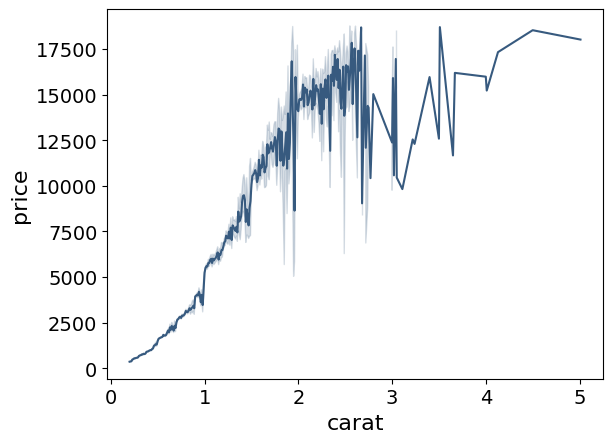

In [60]:
sns.lineplot(cdf, x='carat', y='price')

Of the three, the log-log transformation seems to be the most linear fit, which stands to reason give that both variables are heavily skewed in the same direction.

In [61]:
def get_evar_avgs(evar_list, training_df, cat_cols):
    avg_vals = []
    for col in evar_list:
        if col not in cat_cols:
            avg_val = training_df[col].mean()
        else:
            avg_val = training_df[col].mode().values[0]
        avg_vals.append(avg_val)
    output = {col: val for col, val in zip(evar_list, avg_vals)}
    return output
            

Although we largely used the pyrsm package in school, I'd like to improve my familiarity with more broadly used libraries like scikit learn. There are a lot of features of the pyrsm package I like, and I think I can replicate many of them.

Interesting note, when I predict only one variable, color, the plot of mean price against color mirrors the plot of mean predicted price against color, demonstrating the manner in which the model fits the pattern of the data. Another note, there is difference between mean and median of true price for each color, but there is not for predicted price, which makes sense as each color would have a range of true values but only one predicted value.

Here we can see the model trained only on carat and the clear non-linear pattern that exists. Notably it seems nearly linear while carat < ~3, but then seems to level out. I'll try a few things to address this.

Adding a boolean column to represent carats more than 3 (where it appears to level out) improved the model slightly, but not tremendously. Since I observed the most linear relationship between log_carat and log_price, I'd like try testing that out.

In [133]:
evars = ['carat', 'large', 'carat:large', 'cut', 'color', 'clarity'] #, 'depth_norm', 'irregular', 'color_D:cut_IF']
rvar = ['price']

x_train, x_test, y_train, y_test = train_test_split(
    cdf[evars],
    cdf[rvar],
    test_size=0.2,
    random_state=42
)

train_df = pd.concat([x_train, y_train], axis=1)
test_df = pd.concat([x_test, y_test], axis=1)
cat_cols = [col for col in evars if cdf[col].dtype not in ['int64', 'float64']]

col_transformer = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(drop='first'), cat_cols),
        ('log', FunctionTransformer(np.log, feature_names_out="one-to-one"), ['carat'])
    ],
    remainder='passthrough'
)

x_train_encoded = col_transformer.fit_transform(x_train)
x_test_encoded = col_transformer.transform(x_test)

if type(x_train_encoded) != np.ndarray:
    x_train_encoded = x_train_encoded.toarray()
x_const = sm.add_constant(x_train_encoded)
feature_names = ['intercept'] + list(col_transformer.get_feature_names_out())
x_const_df = pd.DataFrame(x_const, columns=feature_names)

y_train_log = np.log(y_train).reset_index(drop=True)
sm_model = sm.OLS(y_train_log, x_const_df).fit()


model = TransformedTargetRegressor(
    regressor=LinearRegression(),
    func=np.log,
    inverse_func=np.exp
) 
model.fit(x_train_encoded, y_train)


y_pred_train = model.predict(x_train_encoded)
train_df['y_pred'] = y_pred_train
train_df['log_y_pred'] = np.log(train_df.y_pred)
train_df['log_price'] = np.log(train_df.price)
train_df['resid'] = train_df.log_y_pred - train_df.log_price
r2_train = r2_score(train_df.log_price, train_df.log_y_pred)
rmse_train = root_mean_squared_error(train_df.log_price, train_df.log_y_pred)

y_pred_test = model.predict(x_test_encoded)
test_df['y_pred'] = y_pred_test
test_df['log_y_pred'] = np.log(test_df.y_pred)
test_df['log_price'] = np.log(test_df.price)
test_df['resid'] = test_df.log_y_pred - test_df.log_price
r2_test = r2_score(test_df.log_price, test_df.log_y_pred)
rmse_test = root_mean_squared_error(test_df.log_price, test_df.log_y_pred)

print(sm_model.summary())

print('''==============================================================================
''')
print(f'Training Data - R Squared: {round(r2_train, 3)}  RMSE: {round(rmse_train, 3)}')
print(f'Test Data - R Squared: {round(r2_test, 3)}  RMSE: {round(rmse_test, 3)}')

x_vif = x_train.copy()
for col in cat_cols:
    x_vif[col] = x_vif[col].cat.codes
vifs = [round(variance_inflation_factor(x_vif.values, n), 2) for n in range(x_vif.shape[1])]
vif_df = pd.DataFrame(vifs, columns=['VIF Score'], index=x_vif.columns).sort_values('VIF Score', ascending=False)
display(vif_df)


                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 1.253e+05
Date:                Sun, 31 May 2026   Prob (F-statistic):               0.00
Time:                        20:06:08   Log-Likelihood:                 26059.
No. Observations:               43116   AIC:                        -5.208e+04
Df Residuals:                   43095   BIC:                        -5.189e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
intercept                  7

,VIF Score
carat:large,67.87
large,67.27
cut,6.20
clarity,3.93
color,3.75
carat,3.58


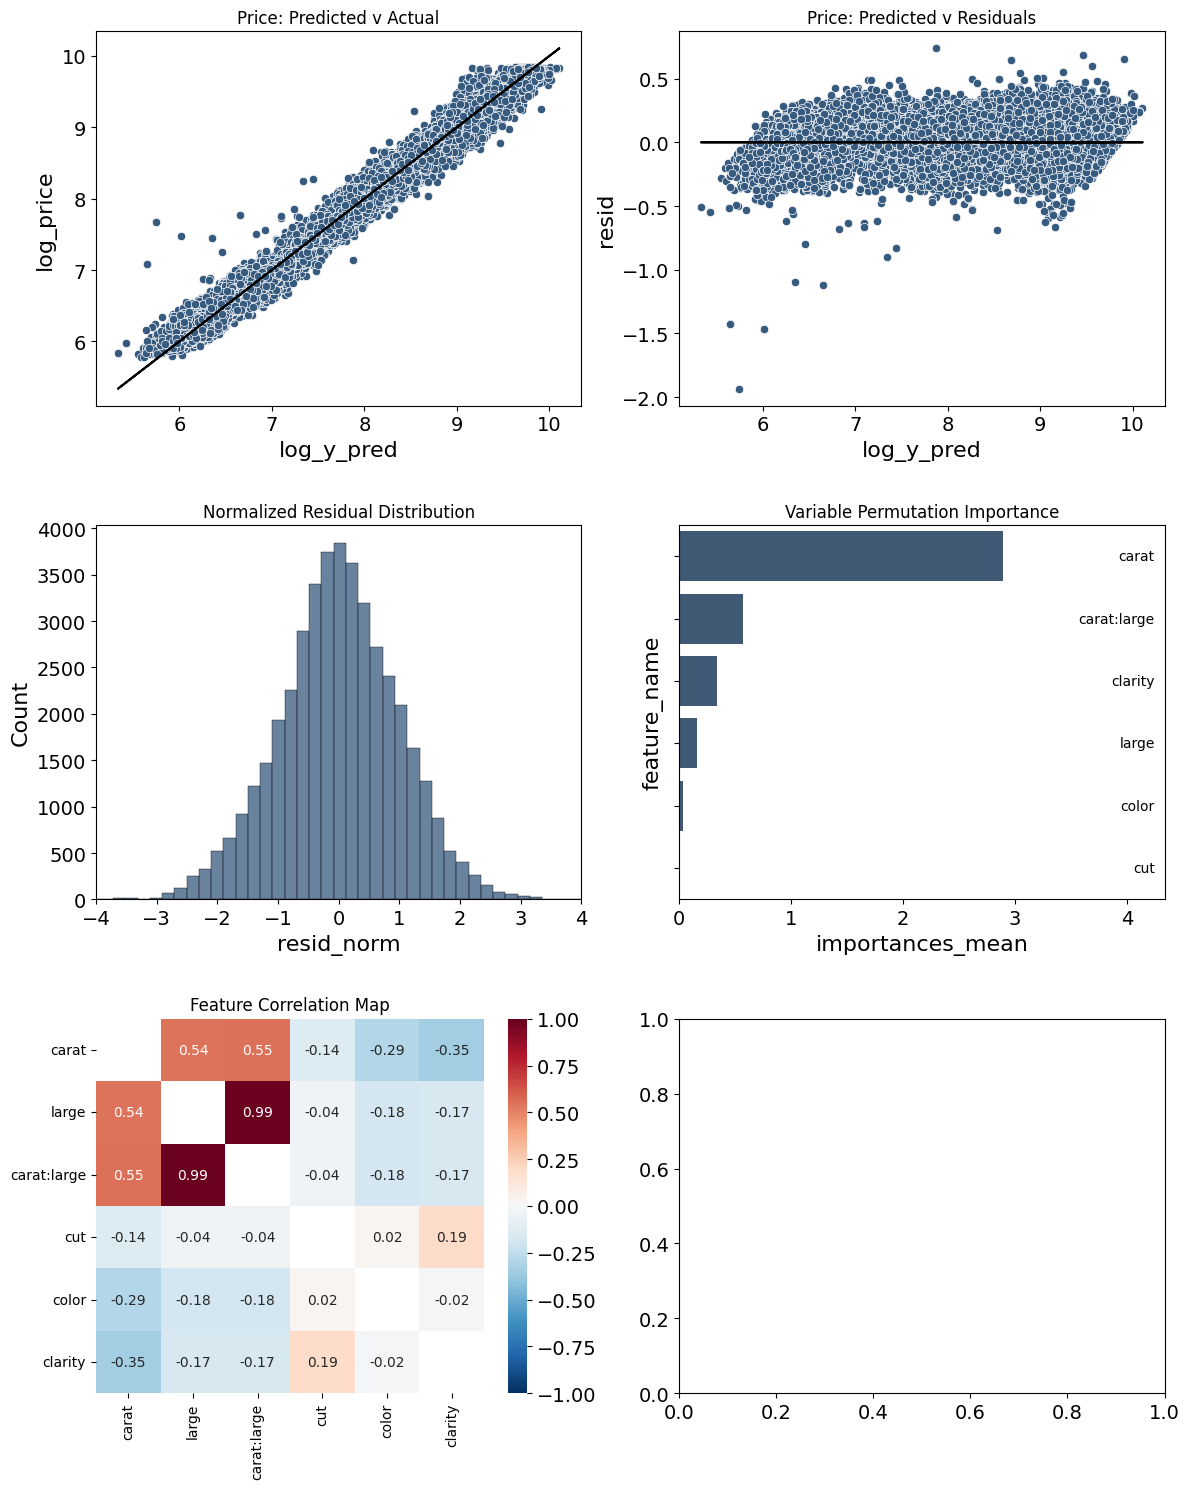

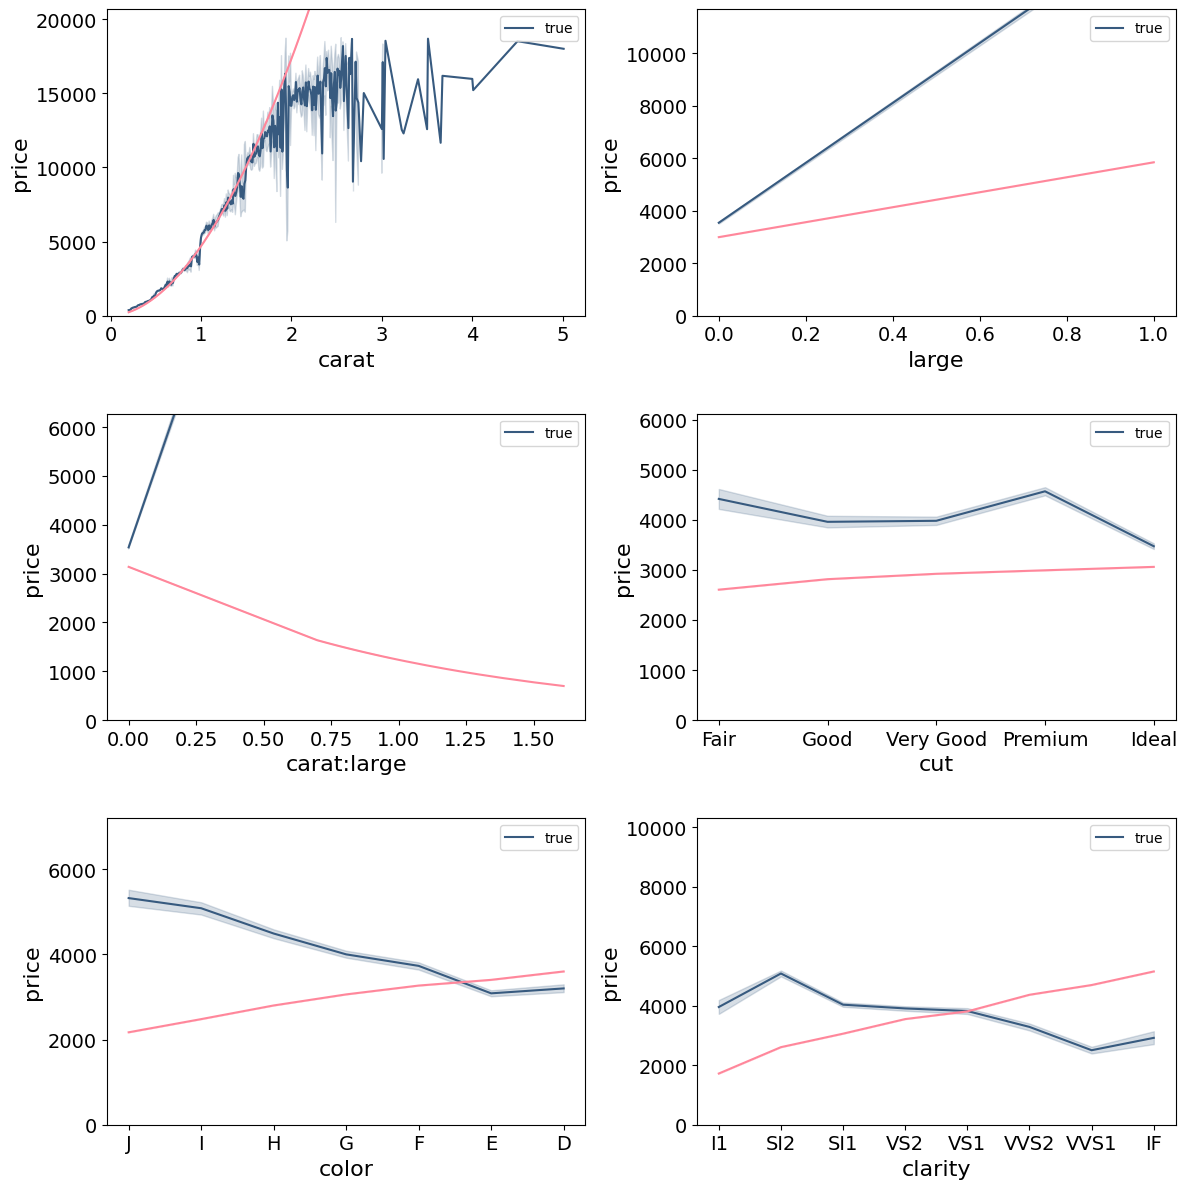

In [134]:
# model diagnostic plots
fig, ax = plt.subplots(3, 2, figsize=(12, 15))
ax = ax.flatten()

sns.scatterplot(train_df, x='log_y_pred', y='log_price', ax=ax[0])
ax[0].plot(train_df.log_y_pred, train_df.log_y_pred, color='black')
ax[0].xlabel = 'Predicted'
ax[0].ylabel = 'Actual'
ax[0].set_title('Price: Predicted v Actual')

sns.scatterplot(train_df, x='log_y_pred', y='resid', ax=ax[1])
ax[1].plot(train_df.log_y_pred, np.zeros(train_df.shape[0]), color='black')
ax[1].xlabel = 'Predicted'
ax[1].ylabel = 'Actual'
ax[1].set_title('Price: Predicted v Residuals')

mean_resid = train_df.resid.mean()
std_resid = train_df.resid.std()
train_df['resid_norm'] = train_df.resid.apply(
    lambda x: (x - mean_resid) / std_resid
)
sns.histplot(train_df, x='resid_norm', bins=100, ax=ax[2])
ax[2].set_xlim(-4, 4)
ax[2].set_title('Normalized Residual Distribution')


vimp = permutation_importance(
    model,
    x_train_encoded,
    y_train,
    random_state=42,
    n_repeats=10
)
vimp_features = col_transformer.get_feature_names_out()
vimp_df = pd.DataFrame({
    'feature': vimp_features,
    'importances_mean': vimp.importances_mean
})
vimp_df['feature_transformer'] = vimp_df.feature.apply(lambda x: x.split('_')[0])
vimp_df['feature_name'] = vimp_df.apply(lambda x: x.feature.split('_')[2] if x.feature_transformer == 'onehot' else x.feature.split('__')[1], axis=1)
vimp_df['feature_value'] = vimp_df.apply(lambda x: x.feature.split('_')[3] if x.feature_transformer == 'onehot' else None, axis=1)
vimp_grp = vimp_df.groupby('feature_name').mean('importances_mean').reset_index().sort_values('importances_mean', ascending=False)
sns.barplot(orient='h', data=vimp_grp, y='feature_name', x='importances_mean', ax=ax[3])
ax[3].set_yticklabels([])
xlim = vimp_grp.importances_mean.max() * 1.5
for i, label in enumerate(vimp_grp.feature_name):
    ax[3].text(xlim*0.98, i, label, ha='right', va='center', fontsize=10)
ax[3].set_xlim(0, xlim)
ax[3].set_title('Variable Permutation Importance')

corr_mtx = x_vif.corr().round(2)
np.fill_diagonal(corr_mtx.values, None)
sns.heatmap(corr_mtx, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax[4])
ax[4].set_title('Feature Correlation Map')
ax[4].tick_params(axis='both', labelsize=10)


plt.tight_layout(h_pad=3)
plt.show()


# feature impact plots
def get_evar_avgs(evar_list, training_df, cat_cols):
    avg_vals = []
    for col in evar_list:
        if col not in cat_cols:
            avg_val = training_df[col].mean()
        else:
            avg_val = training_df[col].mode().values[0]
        avg_vals.append(avg_val)
    output = {col: val for col, val in zip(evar_list, avg_vals)}
    return output
            
avg_evar_vals = get_evar_avgs(evars, x_train, cat_cols)


n_axes = len(evars)
n_plot_rows = int(np.ceil(n_axes/2))

fig, axes = plt.subplots(n_plot_rows, 2, figsize=(12,n_plot_rows*4))
axes = axes.flatten()
plt.rcParams.update(
    {'xtick.labelsize': 14, 'ytick.labelsize': 14, 'axes.labelsize': 16}
)

for a, col in enumerate(evars):

    x_train_synth = x_train.copy()
    other_evars = evars.copy()
    other_evars.remove(col)
    for other_col in other_evars:
        x_train_synth[other_col] = avg_evar_vals[other_col]

    x_train_synth_encoded = col_transformer.transform(x_train_synth)
    x_train_synth['y_pred'] = model.predict(x_train_synth_encoded)
    x_train_synth['price'] = y_train

    sns.lineplot(x_train_synth, x=col, y='price', ax=axes[a], label='true')
    sns.lineplot(x_train_synth, x=col, y='y_pred', ax=axes[a])# , label='pred')
    axes[a].set_ylim(0, min(train_df.price.max()*1.1, x_train_synth.y_pred.max()*2))

plt.tight_layout(h_pad=3)
plt.show()

